# Model profiles at Payerne against the radiosonde, 9 October 2025 00 UTC

The top row of the profile figure in `CLCT_spindown_decomposition.ipynb` shows the four states of
one assimilation cycle -- `lff(T)`, `laf(T)`, `iaf(T)`, `lff(T+1)` -- averaged over Switzerland.
Averaging over the whole country is right for a budget but wrong for a comparison against an
observation, because there is only one radiosonde. This notebook narrows that same figure to

- **one cycle**: 2025-10-09 00 UTC, rather than a multi-day mean,
- **one column**: the model cell containing Payerne, rather than the Swiss box,
- **two variables**: `T` and `RH`, the two the sounding also measures,
- **the top row only**: absolute states, no increments,

and overlays the **Payerne radiosonde** launched for the same nominal time.

## What the sounding contributes

The DWH sounding files hold temperature (`745`), dew point (`747`), wind speed (`748`), wind
direction (`743`), altitude (`742`, above sea level) and pressure (`744`). There is no relative
humidity column, so `RH` is derived from the dew point here. To keep the comparison honest, it is
derived with **exactly** the formula the model side uses -- specific humidity over saturation
specific humidity, Tetens over water -- rather than the more usual vapour-pressure ratio
`e(Td)/e(T)`. The two differ by a fraction of a percent, but only one of them makes the black line
and the coloured lines the same quantity.

## Two caveats to read the figure with

- **Height is above ground, as in the original figure.** The sounding's own ground is its lowest
  valid level; the model's is `HSURF` in the Payerne cell. Those are not the same altitude -- the
  1 km terrain smooths Payerne's position in the Broye valley -- and the offset is printed below so
  the mismatch is visible rather than assumed away.
- **The resolutions differ by two orders of magnitude near the ground.** The sounding reports every
  ~5 m; the model's lowest layer is ~20 m thick and layers thicken quickly with height. A sharp
  observed inversion is therefore expected to look blunter in the model even where the model has it
  exactly right. Nothing is smoothed or interpolated here -- both are drawn as reported.


## 0. Setup

In [1]:

import os
os.environ["ECCODES_VERSION_CHECK_OFF"] = "1"  # must be set before importing earthkit.data

import pickle
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import eccodes            # before earthkit.data, so the native libraries resolve correctly
import earthkit.data as ekd

SAVE_FIGURES = False
SHOW_FIGURES = True

OUTPUT_DIR = Path("./figures/payerne_sounding")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def finish(fig, name):
    """Save a figure and/or draw it inline. Closing before showing gives a blank cell."""
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / name, dpi=150, bbox_inches="tight")
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)

In [2]:

# ============================== what to analyse ==============================
EXP_IDS = ["801", "802"]
BASE_DIR_TMPL = "/store_new/mch/msopr/jdelbeke/ICON_TST/{exp}"
YEAR_SUFFIX = "25"

# The single cycle this notebook is about. lff(T+1) must exist, so this cannot be the
# last cycle on disk (both experiments run to 2025-10-10 00 UTC).
CYCLE = datetime(2025, 10, 9, 0)

PAYERNE = (46.8123, 6.9422)       # radiosonde site; (lat, lon)
STATION_ELEV_M = 490.0            # Payerne station altitude, from the sounding file header

LEVELS_OF_INTEREST = list(range(40, 81))   # 80 layers, described by 81 HHL interfaces

# Top of the height window [m above ground]; None = every level read (level 40 reaches
# about 4150 m here). Near-surface structure is the point, so this sits well below that.
# The axis limits, the sounding clipping and the layer averaging all derive from this one
# number, so there is nowhere for them to drift apart.
MAX_PLOT_Z = 3000.0

# ------------------------------- the sounding -------------------------------
SOUNDINGS_DIR = Path("/scratch/mch/jdelbeke/soundings/output")
STATION_ID = "06610"
MISSING_VALUE = 10000000

print(f"cycle {CYCLE:%Y-%m-%d %H} UTC, experiments {', '.join(EXP_IDS)}")

cycle 2025-10-09 00 UTC, experiments 801, 802


In [3]:

# ============================ plotting conventions ============================
# Same conventions as CLCT_spindown_decomposition, so the panels are read the same way:
# colour = experiment, line style = file. The sounding is the one thing that is neither,
# so it gets black and a weight no model line uses.
EXP_COLOUR = {"801": "#0072B2", "802": "#D55E00"}

STAGES = ["lff", "laf", "iaf", "lff1"]
STAGE_STYLE = {
    "lff":  ("--",  "lff(T) = first guess"),
    "laf":  ("-",   "laf(T) = uninitialized ana"),
    "iaf":  ("-.",  "iaf(T) = initialized ana"),
    "lff1": (":",   "lff(T+1) = first guess, next cycle"),
}

OBS_COLOUR = "k"
OBS_LW = 2.2

VAR_UNITS = {"T": "degC", "RH": "%"}
PLOT_VARS = ["T", "RH"]
HEIGHT_LABEL = "height above ground [m]"


def orient_vertical(ax, z, z_top):
    """Ground at the bottom of the axis, model top at the top.

    An explicit set_ylim rather than invert_yaxis(): the profiles are stored top-first, so
    the natural limits come out upside down, and invert_yaxis() *toggles* - with sharey=True
    one call per panel flips an even number of times and lands back where it started.

    z_top is passed in rather than read off MAX_PLOT_Z as a global, so the height window is
    decided in one place and the axis cannot disagree with the data clipping.
    """
    ax.set_ylim(np.min(z), z_top)


def profile_legend(fig, **kw):
    """Experiments (coloured), then the file line styles (grey), then the sounding.

    Placed below the panels rather than inside one. With two narrow panels and eight model
    lines converging near the ground there is no reliably empty corner, and an in-axes
    legend covered the temperature profile outright.
    """
    handles = [Line2D([], [], color=EXP_COLOUR[e], ls="-", lw=2.6, label=e) for e in EXP_IDS]
    handles += [Line2D([], [], color="0.25", ls=s, lw=1.6, label=lab)
                for s, lab in STAGE_STYLE.values()]
    handles += [Line2D([], [], color=OBS_COLOUR, ls="-", lw=OBS_LW,
                       label="Payerne radiosonde")]
    fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False, **kw)

### Reading the files

Unchanged from `CLCT_spindown_decomposition`: each of these GRIB files holds 1200-1500 messages,
and this notebook wants three variables on 41 levels in a *single* column. `Grib` indexes a file
with a headers-only pass, caches that index on disk, and then reads only the messages asked for by
seeking to their offsets.

The saving is larger here than in the parent notebook, not smaller: one cycle, one column. Note
though that ecCodes decodes a whole GRIB message at a time -- there is no way to decode one cell of
one field -- so the cost is set by the number of *messages* (41 levels x 3 variables x 4 files),
not by the single column that survives.


In [4]:

def file_path(exp_id, kind, time):
    """kind: "lff"/"iff" (first-guess archive) or "inc"/"iaf"/"laf" (analysis archive)."""
    base = BASE_DIR_TMPL.format(exp=exp_id)
    sub = ("FG" if kind in ("lff", "iff") else "ANA") + YEAR_SUFFIX
    return os.path.join(base, sub, "det", f"{kind}{time:%Y%m%d%H}")


CACHE_DIR = Path(f"/scratch/mch/{os.environ['USER']}/spindown_grib_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def build_index(path):
    """shortName -> [(level, byte offset, byte length), ...], sorted by level."""
    index = {}
    with open(path, "rb") as f:
        while True:
            h = eccodes.codes_grib_new_from_file(f, headers_only=True)
            if h is None:
                break
            index.setdefault(eccodes.codes_get(h, "shortName"), []).append(
                (eccodes.codes_get_long(h, "level"),
                 eccodes.codes_get_message_offset(h),
                 eccodes.codes_get_long(h, "totalLength")))
            eccodes.codes_release(h)
    for entries in index.values():
        # Sorted by level, so every profile comes back in one fixed order: index 0 is the
        # *highest* level requested, the last index is the one nearest the ground. (The
        # parent notebook's comment here reads "ground-up", which is backwards - checked
        # against the files, profile("T", range(40, 81)) returns level 40 first.)
        entries.sort()
    return index


def load_index(path):
    """build_index, cached on disk. Key is (name, size, mtime), so a regenerated file
    invalidates its own entry rather than returning a stale index.

    This is the same cache directory the parent notebook writes, so if that has been run
    over this period the index pass here is free."""
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    stat = os.stat(path)
    cached = CACHE_DIR / f"{Path(path).name}_{stat.st_size}_{stat.st_mtime_ns}.pkl"
    if cached.exists():
        with open(cached, "rb") as fh:
            return pickle.load(fh)
    index = build_index(path)
    tmp = cached.with_suffix(f".tmp{os.getpid()}")
    with open(tmp, "wb") as fh:
        pickle.dump(index, fh, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(tmp, cached)
    return index


_grid = None


def grid_lonlat(path):
    """Cell longitudes and latitudes, via earthkit once and cached thereafter.

    ecCodes will not expand the coordinates of this unstructured (triangular) grid, so one
    field has to go through earthkit. Every file shares the same grid.
    """
    global _grid
    if _grid is not None:
        return _grid
    npz = CACHE_DIR / "icon_grid_lonlat.npz"
    if npz.exists():
        z = np.load(npz)
        _grid = (z["lon"], z["lat"])
    else:
        xa = ekd.from_source("file", path).to_fieldlist()[0].to_xarray()
        _grid = (xa["longitude"].values, xa["latitude"].values)
        np.savez(npz, lon=_grid[0], lat=_grid[1])
    return _grid


class Grib:
    """One GRIB file, indexed by variable name, decoding only the messages asked for."""

    def __init__(self, path):
        self.path = path
        self.index = load_index(path)

    def _read(self, entries):
        values = []
        with open(self.path, "rb") as f:
            for _, offset, length in entries:
                f.seek(offset)
                h = eccodes.codes_new_from_message(f.read(length))
                values.append(eccodes.codes_get_values(h))
                eccodes.codes_release(h)
        return np.array([e[0] for e in entries]), np.stack(values)

    def profile(self, short_name, levels=None):
        """Multi-level field -> (levels, array of shape (n_levels, n_cells))."""
        entries = self.index[short_name]
        if levels is not None:
            want = {int(lev) for lev in levels}
            entries = [e for e in entries if e[0] in want]
        return self._read(entries)

    def field(self, short_name):
        """Single-level field -> values."""
        return self._read(self.index[short_name][:1])[1][0]

    @property
    def lonlat(self):
        return grid_lonlat(self.path)


def nearest_cell(lon, lat, target):
    """Index of the model cell nearest to (lat, lon), on the sphere.

    A straight argmin on the dot product rather than a cKDTree: building the tree sorts all
    1.1M cells to answer a single query, and maximising the dot product picks exactly the
    cell that minimising great-circle distance would.
    """
    la, lo = np.deg2rad(lat), np.deg2rad(lon)
    la0, lo0 = np.deg2rad(target[0]), np.deg2rad(target[1])
    dot = (np.cos(la) * np.cos(lo) * np.cos(la0) * np.cos(lo0) +
           np.cos(la) * np.sin(lo) * np.cos(la0) * np.sin(lo0) +
           np.sin(la) * np.sin(la0))
    return int(np.argmax(dot))

### Relative humidity, defined once

`RH` is not in either the GRIB files or the sounding files; both sides derive it. The parent
notebook forms the model's as specific humidity over saturation specific humidity, with Tetens over
water, and the same two functions are used here for the sounding -- the dew point is turned into a
specific humidity first, then divided by the saturation specific humidity at the *measured*
temperature and pressure.

Using the same code for both is the whole point. Had the sounding's `RH` been formed the textbook
way as `e(Td)/e(T)`, the black line and the coloured lines would be slightly different quantities,
and a systematic model-observation difference of a few tenths of a percent would be an artefact of
the notebook rather than a property of the forecast.

Note that this is saturation over *water* at all heights, including well below freezing, where
operational practice sometimes switches to ice. Over water throughout is what the parent notebook
does, so it is what is done here; it means sub-zero `RH` values are directly comparable between the
two figures but are not the same convention as a WMO-reported `RH`.


In [5]:

def saturation_qv(T_k, p_pa):
    """Saturation specific humidity from temperature [K] and pressure [Pa] (Tetens, over water)."""
    T_c = T_k - 273.15
    e_s = 611.2 * np.exp(17.62 * T_c / (243.12 + T_c))
    return 0.622 * e_s / np.clip(p_pa - 0.378 * e_s, 1.0, None)


def relative_humidity(qv, T_k, p_pa):
    """RH [%] from specific humidity, temperature [K] and pressure [Pa]."""
    return 100.0 * qv / saturation_qv(T_k, p_pa)


def qv_from_dewpoint(Td_k, p_pa):
    """Specific humidity from dew point [K] and pressure [Pa].

    Saturation specific humidity evaluated at the dew point *is* the actual specific
    humidity, by the definition of dew point - so this is saturation_qv again, and the
    sounding and the model end up sharing every constant.
    """
    return saturation_qv(Td_k, p_pa)

## 1. The model column at Payerne

Four files per experiment, three variables (`T`, `QV`, `P`) on levels 40-80, reduced to the single
cell containing Payerne. `laf(T)` is reconstructed as `lff(T) + inc(T)` rather than read from disk,
exactly as in the parent notebook: identical to rounding, and one fewer file to open.

`RH` is formed *per stage* from that stage's own `T`, `QV` and `P`. It cannot be formed from an `RH`
increment, because relative humidity is non-linear in both temperature and humidity.


In [6]:

def model_column(exp_id, t, cell, levels=LEVELS_OF_INTEREST):
    """The four states at one cycle, in one column: T [K], QV, P and derived RH."""
    lff = Grib(file_path(exp_id, "lff", t))
    inc = Grib(file_path(exp_id, "inc", t))
    iaf = Grib(file_path(exp_id, "iaf", t))
    lff1 = Grib(file_path(exp_id, "lff", t + pd.Timedelta(hours=1)))

    def col(grib, var):
        return grib.profile(var, levels)[1][:, cell]

    out = {}
    for var in ("T", "QV", "P"):
        a_lff, a_inc = col(lff, var), col(inc, var)
        out[("lff", var)] = a_lff
        out[("laf", var)] = a_lff + a_inc      # exact to rounding; saves reading laf
        out[("iaf", var)] = col(iaf, var)
        out[("lff1", var)] = col(lff1, var)

    for stage in STAGES:
        out[(stage, "RH")] = relative_humidity(out[(stage, "QV")],
                                               out[(stage, "T")], out[(stage, "P")])
        # Plotted in degC so the sounding needs no unit conversion of its own.
        out[(stage, "T")] = out[(stage, "T")] - 273.15
    return out


# ---- geometry: the Payerne cell, and the height of each layer centre above ground ----
_lff0 = Grib(file_path(EXP_IDS[0], "lff", CYCLE))
_iaf0 = Grib(file_path(EXP_IDS[0], "iaf", CYCLE))
lon, lat = _lff0.lonlat
PAY_CELL = nearest_cell(lon, lat, PAYERNE)

_lev = np.array(sorted(LEVELS_OF_INTEREST))
# Layer L is bounded by HHL interfaces L and L+1, so the layers of interest need one
# interface more than they have levels.
_, _hhl = _iaf0.profile("HHL", range(int(_lev.min()), int(_lev.max()) + 2))
_hhl = _hhl[:, PAY_CELL]
hsurf_pay = float(_lff0.field("HSURF")[PAY_CELL])
# Interfaces and centres, both above ground. Top-first, matching the data arrays: bound k
# is the top of layer k and bound k+1 its base. Section 4 averages the sounding between
# them, so the bounds are kept rather than only their midpoints.
z_bounds = _hhl - hsurf_pay
z_prof = 0.5 * (z_bounds[:-1] + z_bounds[1:])          # layer centre, above ground [m]

_d_km = 6371.0 * np.arccos(np.clip(
    np.sin(np.deg2rad(PAYERNE[0])) * np.sin(np.deg2rad(lat[PAY_CELL])) +
    np.cos(np.deg2rad(PAYERNE[0])) * np.cos(np.deg2rad(lat[PAY_CELL])) *
    np.cos(np.deg2rad(lon[PAY_CELL] - PAYERNE[1])), -1, 1))

print(f"Payerne cell {PAY_CELL}: {lat[PAY_CELL]:.4f}N {lon[PAY_CELL]:.4f}E, "
      f"{_d_km * 1000:.0f} m from the station")
print(f"model terrain height there: {hsurf_pay:.1f} m, station: {STATION_ELEV_M:.0f} m "
      f"-> model ground is {hsurf_pay - STATION_ELEV_M:+.1f} m relative to the launch site")
print(f"levels {_lev.min()}-{_lev.max()}: layer centres "
      f"{z_prof[-1]:.0f} m to {z_prof[0]:.0f} m above ground")
print(f"lowest layer is {z_bounds[-2] - z_bounds[-1]:.1f} m thick, "
      f"the layer at {MAX_PLOT_Z:.0f} m is "
      f"{-np.diff(z_bounds)[np.argmin(np.abs(z_prof - MAX_PLOT_Z))]:.0f} m thick")
# HHL interface 81 is the ground: this should print 0.0, and is the check that the
# above-ground conversion used the right interface.
print(f"lowest interface above ground: {z_bounds[-1]:.3f} m (0 = HSURF, as expected)")

state_prof = {}
for exp_id in EXP_IDS:
    cols = model_column(exp_id, CYCLE, PAY_CELL)
    for stage in STAGES:
        for var in PLOT_VARS:
            state_prof[(exp_id, stage, var)] = cols[(stage, var)]
print(f"\nread {len(EXP_IDS)} experiments x {len(STAGES)} stages")

Payerne cell 746375: 46.8128N 6.9387E, 274 m from the station
model terrain height there: 468.6 m, station: 490 m -> model ground is -21.4 m relative to the launch site
levels 40-80: layer centres 10 m to 4148 m above ground
lowest layer is 20.0 m thick, the layer at 3000 m is 148 m thick
lowest interface above ground: 0.015 m (0 = HSURF, as expected)

read 2 experiments x 4 stages


## 2. The Payerne sounding

One day's file holds every launch of that day, stacked, distinguished by `termin`. The parsing
below is the same as in `sc_inv_finder.ipynb` and `inv_timeseries.ipynb`, with two changes.

First, it keeps **five** columns rather than two -- height, temperature, dew point *and* pressure --
because `RH` needs all of them. Missing values are masked per column before anything is computed,
and the sentinel is per-field: the hygrometer drops out at heights where the thermometer is still
reporting, so the dew-point profile is generally shorter than the temperature profile from the same
launch. The rows are therefore dropped on `[height, temperature, pressure]` and the dew point is
allowed to stay `NaN`, so a missing humidity reading costs the humidity panel that level rather
than costing the temperature panel a level too.

Second, the `level = -100` header row is excluded **explicitly** rather than as a side effect. That
row carries `742 = 85.00` and `744 = 1000.00` with every measured field set to the sentinel; the
existing notebooks survive it only because `.dropna()` on temperature happens to take it out. Since
this notebook keeps a different set of columns, relying on that would eventually put a spurious
85 m level at the base of a profile and shift the whole height normalisation.


In [7]:

# Column names are DWH numeric parameter IDs.
SND = {"742": "height", "745": "temperature", "747": "dewpoint", "744": "pressure"}


def read_sounding(file):
    """Parse one day's raw sounding file (all termins, all levels)."""
    with open(file) as f:
        header = f.readlines()[1].split()
    return pd.read_csv(
        file, sep=r"\s*\|\s*", engine="python",
        skiprows=3, header=None, names=header,
    )


def load_profile(file, termin):
    """The T / Td / p / z profile of one launch, ground-relative, with RH derived.

    Height is expressed above the lowest valid level of that launch - a proxy for height
    above the launch site, the same convention the inversion notebooks use.
    """
    df = read_sounding(file)
    df = df[df["level"] >= 0]                 # drop the level = -100 header row explicitly
    df = df[df["termin"].astype(str) == str(termin)]
    if df.empty:
        raise ValueError(f"no launch {termin} in {file}")

    prof = (df[list(SND)].replace(MISSING_VALUE, np.nan).rename(columns=SND)
            .dropna(subset=["height", "temperature", "pressure"])   # dewpoint may stay NaN
            .sort_values("height")
            .groupby("height", as_index=False).mean())
    prof["z_agl"] = prof["height"] - prof["height"].iloc[0]

    # Same formula as the model side: dew point -> specific humidity -> RH.
    # Sounding units are degC and hPa; the helpers want K and Pa.
    p_pa = prof["pressure"].to_numpy() * 100.0
    qv = qv_from_dewpoint(prof["dewpoint"].to_numpy() + 273.15, p_pa)
    prof["RH"] = relative_humidity(qv, prof["temperature"].to_numpy() + 273.15, p_pa)
    prof["T"] = prof["temperature"]
    return prof


snd_file = SOUNDINGS_DIR / f"{CYCLE:%Y%m%d}_{STATION_ID}_data.txt"
TERMIN = f"{CYCLE:%Y%m%d%H}0000"
snd = load_profile(snd_file, TERMIN)

print(f"{snd_file.name}, launch {TERMIN}: {len(snd)} levels, "
      f"{snd['z_agl'].iloc[0]:.0f}-{snd['z_agl'].iloc[-1]:.0f} m above the launch site")
print(f"launch site altitude from the file: {snd['height'].iloc[0]:.0f} m "
      f"(station elevation {STATION_ELEV_M:.0f} m)")
print(f"median vertical spacing: {np.median(np.diff(snd['z_agl'])):.1f} m, "
      f"against {z_bounds[-2] - z_bounds[-1]:.1f} m for the model's lowest layer")
print(f"dew point missing on {int(snd['dewpoint'].isna().sum())} of {len(snd)} levels")
_in_range = snd[snd["z_agl"] <= (MAX_PLOT_Z if MAX_PLOT_Z is not None else np.inf)]
print(f"{len(_in_range)} sounding levels inside the plotted height range")

20251009_06610_data.txt, launch 20251009000000: 6920 levels, 0-36788 m above the launch site
launch site altitude from the file: 491 m (station elevation 490 m)
median vertical spacing: 5.0 m, against 20.0 m for the model's lowest layer
dew point missing on 0 of 6920 levels
548 sounding levels inside the plotted height range


## 3. The figure

The four states, in the Payerne column, against the sounding. Colour is the experiment and line
style is the file, exactly as in the parent notebook, so the two figures can be read side by side;
the sounding is black and heavier than any model line.

What to look for: the four coloured lines are one hour of one cycle apart, so where they lie on top
of each other the assimilation did nothing at that height, and where they fan out it did. Whether
the fan moves *towards* the black line is the question the parent notebook could not ask.


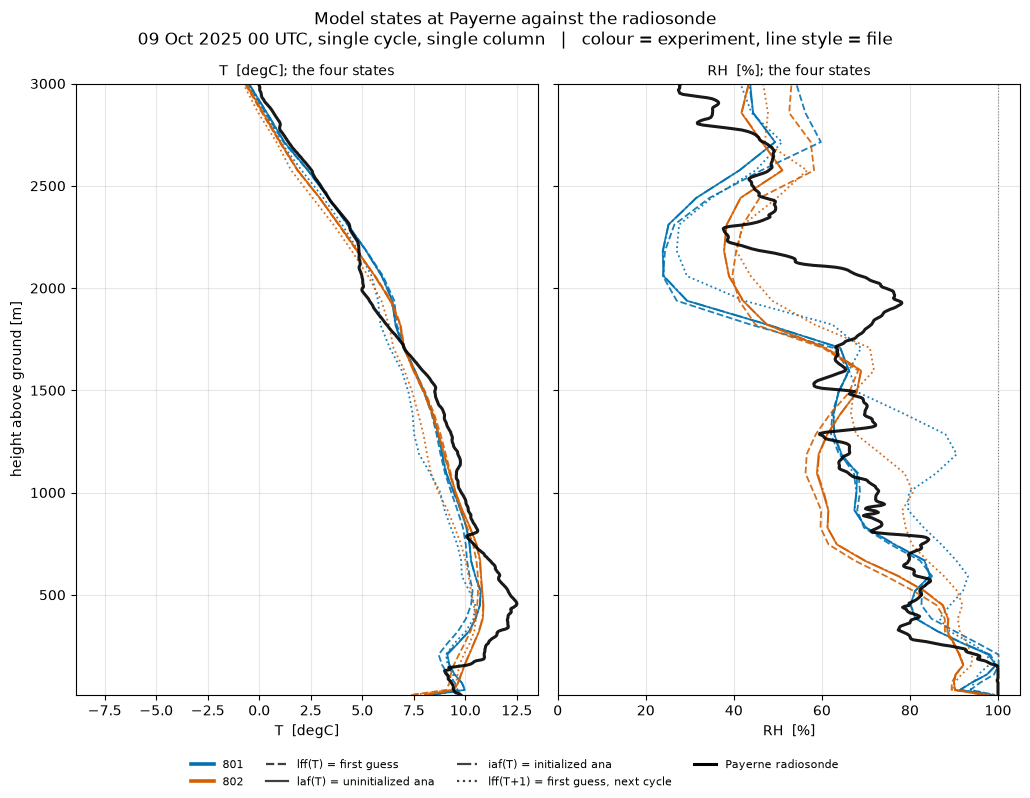

In [8]:

fig, axes = plt.subplots(1, len(PLOT_VARS), figsize=(5.2 * len(PLOT_VARS), 8.0), sharey=True)

# Height limit of the window, resolved once and reused by the axis and by every clip below.
# Without this the sounding is drawn to 37 km, and although those levels sit outside the
# y limits they still set the *x* limits - which pulled the temperature axis out to -60 degC
# and squeezed the 3 km of profile actually on display into a fifth of the panel.
z_top = z_prof.max() if MAX_PLOT_Z is None else MAX_PLOT_Z

for col, var in enumerate(PLOT_VARS):
    ax = axes[col]
    for exp_id in EXP_IDS:
        for stage in STAGES:
            ls, _ = STAGE_STYLE[stage]
            ax.plot(state_prof[(exp_id, stage, var)], z_prof, ls,
                    color=EXP_COLOUR[exp_id], lw=1.3, alpha=0.9)

    # One level past the top, so the black line reaches the axis edge instead of stopping short.
    obs = snd.dropna(subset=[var])
    obs = obs[obs["z_agl"] <= z_top + 50.0]
    ax.plot(obs[var], obs["z_agl"], "-", color=OBS_COLOUR, lw=OBS_LW, alpha=0.9, zorder=5)

    ax.set_title(f"{var}  [{VAR_UNITS[var]}]; the four states", fontsize=10)
    ax.set_xlabel(f"{var}  [{VAR_UNITS[var]}]")
    ax.grid(alpha=0.3)
    orient_vertical(ax, z_prof, z_top)
    if var == "RH":
        ax.set_xlim(0, 105)
        ax.axvline(100, color="0.5", lw=0.8, ls=":")   # saturation

axes[0].set_ylabel(HEIGHT_LABEL)
profile_legend(fig, fontsize=8)
plt.suptitle("Model states at Payerne against the radiosonde\n"
             f"{CYCLE:%d %b %Y %H} UTC, single cycle, single column   |   "
             "colour = experiment, line style = file")
plt.tight_layout(rect=(0, 0.05, 1, 1))     # leave room for the legend below
finish(fig, f"payerne_states_{CYCLE:%Y%m%d%H}.png")

## 4. Deviation from the sounding

Taking the sounding as the reference and plotting `model - sounding` makes the eight model lines
comparable to each other in a way section 3 cannot: differences of a few tenths of a degree between
the four states are invisible against a profile that spans 12 degrees, but they are the whole signal
when the common part is removed.

### Differences are in native units, not percent

"Relative difference" is the natural phrase but the wrong quantity here. A percentage difference in
temperature depends entirely on the unit -- 1 K out of 283 K is 0.4%, the same error out of 10 degC
is 10%, and neither number means anything physical. So temperature is shown as a difference in K and
relative humidity as a difference in **percentage points**, both of which are the units the error
would be reported in anyway. Zero is drawn, and the sign convention is the parent notebook's:
positive means the model is warmer or moister than the sounding.

### Putting the two on a common grid

The sounding reports every ~5 m, the model carries layers 20 m thick at the ground and hundreds of
metres higher up, so one of them has to be moved onto the other's grid. Moving the sounding is the
only defensible direction -- interpolating the model to 5 m would invent structure it does not have.

Within that, the sounding is **averaged over each model layer** rather than sampled at the layer
centre. A model level is a finite-volume layer mean, not a point value, so a layer mean of the
observation is the like-for-like comparison; point-sampling a sharp inversion at the centre of a
300 m layer would charge the model with an error that is really a representativeness mismatch. The
number of sounding levels falling in each layer is reported, since the argument only holds where
that count is comfortably above one.

### The one caveat that does not go away

Model ground at the Payerne cell is about 21 m below the station, and an above-ground axis forces
the two to share a zero. Near-surface differences therefore carry a vertical displacement of roughly
one model layer that no amount of averaging removes. `HEIGHT_REF` below switches the whole
comparison to above-sea-level alignment instead, which trades that away for a model layer that is
partly underground; the printed summary is worth checking both ways before leaning on a
near-surface number.


In [9]:
# "agl" aligns model ground with the launch site (shared zero, ~21 m of terrain error);
# "asl" aligns true altitudes instead (honest heights, lowest model layer partly below the
# station). Section 3 is always above-ground; this switch affects section 4 only.
HEIGHT_REF = "agl"

if HEIGHT_REF == "agl":
    obs_z = snd["z_agl"].to_numpy()
    mod_bounds, mod_centres = z_bounds, z_prof
elif HEIGHT_REF == "asl":
    obs_z = snd["height"].to_numpy()
    mod_bounds, mod_centres = z_bounds + hsurf_pay, z_prof + hsurf_pay
else:
    raise ValueError(f"HEIGHT_REF must be 'agl' or 'asl', not {HEIGHT_REF!r}")


def sounding_on_model_layers(values, obs_z, bounds):
    """Average the sounding over each model layer.

    `bounds` is top-first, so layer k runs from bounds[k+1] (base) up to bounds[k] (top).
    Returns the layer means and the number of sounding levels behind each one; a layer with
    no levels in it comes back NaN rather than being filled from a neighbour, so gaps stay
    visible in the figure instead of being quietly interpolated over.
    """
    values = np.asarray(values, dtype=float)
    means = np.full(len(bounds) - 1, np.nan)
    counts = np.zeros(len(bounds) - 1, dtype=int)
    for k in range(len(bounds) - 1):
        base, top = bounds[k + 1], bounds[k]
        # Half-open on the top so a level on a shared interface is counted once, not twice.
        sel = (obs_z >= base) & (obs_z < top) & np.isfinite(values)
        counts[k] = int(sel.sum())
        if counts[k]:
            means[k] = values[sel].mean()
    return means, counts


obs_layer, obs_count = {}, {}
for var in PLOT_VARS:
    obs_layer[var], obs_count[var] = sounding_on_model_layers(
        snd[var].to_numpy(), obs_z, mod_bounds)

_win = mod_centres <= z_top
print(f"height reference: {HEIGHT_REF}")
for var in PLOT_VARS:
    c = obs_count[var][_win]
    print(f"{var}: {int((c > 0).sum())}/{int(_win.sum())} model layers in the window have "
          f"sounding levels; per-layer count min {c[c > 0].min()}, "
          f"median {int(np.median(c[c > 0]))}, max {c.max()}")
if min(obs_count[v][_win].min() for v in PLOT_VARS) == 0:
    print("note: some layers in the window hold no sounding level and are left as gaps")

height reference: agl
T: 33/33 model layers in the window have sounding levels; per-layer count min 1, median 16, max 28
RH: 33/33 model layers in the window have sounding levels; per-layer count min 1, median 16, max 28


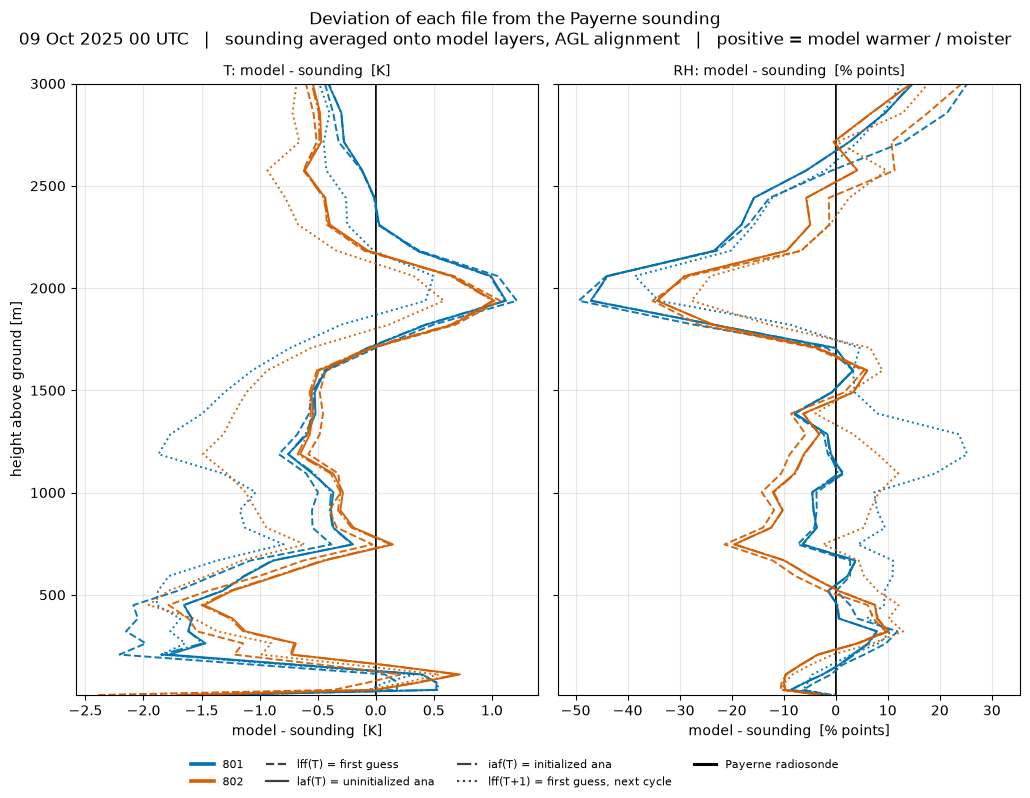

In [10]:
diff_prof = {(e, s, v): state_prof[(e, s, v)] - obs_layer[v]
             for e in EXP_IDS for s in STAGES for v in PLOT_VARS}

DIFF_UNITS = {"T": "K", "RH": "% points"}

fig, axes = plt.subplots(1, len(PLOT_VARS), figsize=(5.2 * len(PLOT_VARS), 8.0), sharey=True)

for col, var in enumerate(PLOT_VARS):
    ax = axes[col]
    for exp_id in EXP_IDS:
        for stage in STAGES:
            ls, _ = STAGE_STYLE[stage]
            ax.plot(diff_prof[(exp_id, stage, var)], mod_centres, ls,
                    color=EXP_COLOUR[exp_id], lw=1.4, alpha=0.95)
    ax.axvline(0, color="k", lw=1.4, zorder=1)     # the sounding, by construction
    ax.set_title(f"{var}: model - sounding  [{DIFF_UNITS[var]}]", fontsize=10)
    ax.set_xlabel(f"model - sounding  [{DIFF_UNITS[var]}]")
    ax.grid(alpha=0.3)
    orient_vertical(ax, mod_centres, z_top)

axes[0].set_ylabel(HEIGHT_LABEL if HEIGHT_REF == "agl" else "height above sea level [m]")
profile_legend(fig, fontsize=8)
plt.suptitle("Deviation of each file from the Payerne sounding\n"
             f"{CYCLE:%d %b %Y %H} UTC   |   sounding averaged onto model layers, "
             f"{HEIGHT_REF.upper()} alignment   |   positive = model warmer / moister")
plt.tight_layout(rect=(0, 0.05, 1, 1))
finish(fig, f"payerne_deviation_{CYCLE:%Y%m%d%H}.png")